In [1]:
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
from src.dataset.tiny_imagenet_dataset import TinyImageNetLoader
from archive.pc_cnn.py_file.pc_8_classify import HierarchicalPCCNN

In [2]:
SEED = 42
BATCH_SIZE = 16

NUM_CLASSES = 5

TRAIN_IMAGES_PER_CLASS = 50
VAL_IMAGES_PER_CLASS = 15
TEST_IMAGES_PER_CLASS = 10

INFERENCE_STEPS = 100

PC_EPOCHS = 50
CLASSIFICATION_EPOCHS = 10

CLASSIFIER_LEARNING_RATE = 0.01

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available() and hasattr(torch.mps, "manual_seed"):
    torch.mps.manual_seed(SEED)

Device: mps


In [4]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(TinyImageNetLoader(seed=SEED), image_size=64).load()

train_dataset = cleaned_tiny_imagenet[0]
test_dataset = cleaned_tiny_imagenet[1]

print("Full training dataset:", len(train_dataset))
print("Full test dataset:", len(test_dataset))

Full training dataset: 99953
Full test dataset: 9993


In [5]:
selected_classes = list(range(NUM_CLASSES))

print("Selected classes:", selected_classes)
print("Number of selected classes:", len(selected_classes))

Selected classes: [0, 1, 2, 3, 4]
Number of selected classes: 5


In [6]:
class_indices = defaultdict(list)

for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    label = int(label)

    if label in selected_classes:
        class_indices[label].append(i)

In [7]:
split_generator = torch.Generator()
split_generator.manual_seed(SEED)

train_indices = []
val_indices = []

for class_id in selected_classes:
    available_indices = class_indices[class_id]

    required_images = TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS

    if len(available_indices) < required_images:
        raise ValueError(
            f"Class {class_id} has only {len(available_indices)} images, but {required_images} are required.")

    permutation = torch.randperm(len(available_indices), generator=split_generator)

    train_selection = permutation[:TRAIN_IMAGES_PER_CLASS]
    train_selected = [available_indices[i] for i in train_selection.tolist()]

    val_start = TRAIN_IMAGES_PER_CLASS
    val_end = TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS

    val_selection = permutation[val_start:val_end]
    val_selected = [available_indices[i] for i in val_selection.tolist()]

    train_indices.extend(train_selected)
    val_indices.extend(val_selected)

In [8]:
train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))

print("Expected training images:", NUM_CLASSES * TRAIN_IMAGES_PER_CLASS)
print("Expected validation images:", NUM_CLASSES * VAL_IMAGES_PER_CLASS)

Training images: 250
Validation images: 75
Expected training images: 250
Expected validation images: 75


In [9]:
train_index_set = set(train_indices)
val_index_set = set(val_indices)

overlap = train_index_set.intersection(val_index_set)

print("Train/Validation overlap:", len(overlap))

assert len(overlap) == 0

Train/Validation overlap: 0


In [10]:
train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(SEED)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, generator=train_loader_generator)

train_eval_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Training batches:", len(train_loader))
print("Train evaluation batches:", len(train_eval_loader))
print("Validation batches:", len(val_loader))

Training batches: 16
Train evaluation batches: 16
Validation batches: 5


In [11]:
test_class_indices = defaultdict(list)

for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    label = int(label)

    if label in selected_classes:
        test_class_indices[label].append(i)

In [12]:
test_generator = torch.Generator()
test_generator.manual_seed(SEED)

test_indices = []

for class_id in selected_classes:
    available_indices = test_class_indices[class_id]

    if len(available_indices) < TEST_IMAGES_PER_CLASS:
        raise ValueError(
            f"Test class {class_id} has only {len(available_indices)} images, but {TEST_IMAGES_PER_CLASS} were requested.")

    permutation = torch.randperm(len(available_indices), generator=test_generator)
    selection = permutation[:TEST_IMAGES_PER_CLASS]

    selected = [available_indices[i] for i in selection.tolist()]
    test_indices.extend(selected)

In [13]:
test_subset = Subset(test_dataset, test_indices)

test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Training images per class:", TRAIN_IMAGES_PER_CLASS)
print("Validation images per class:", VAL_IMAGES_PER_CLASS)
print("Test images per class:", TEST_IMAGES_PER_CLASS)

print("Total training images:", len(train_subset))
print("Total validation images:", len(val_subset))
print("Total test images:", len(test_subset))

Training images per class: 50
Validation images per class: 15
Test images per class: 10
Total training images: 250
Total validation images: 75
Total test images: 50


In [14]:
model = HierarchicalPCCNN(num_classes=NUM_CLASSES, inference_steps=INFERENCE_STEPS).to(device)

print(model)

HierarchicalPCCNN(
  (level1): ModuleDict(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (level2): ModuleDict(
    (conv): Conv2d(32, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(128, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (classifier_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Linear(in_features=2048, out_features=5, bias=True)
)


In [15]:
total_params = sum(parameter.numel() for parameter in model.parameters())
autograd_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print("Total unique parameters:", total_params)
print("Autograd-enabled parameters:", autograd_params)

assert autograd_params == 0

Total unique parameters: 47973
Autograd-enabled parameters: 0


In [16]:
pc_history = []

for epoch in range(PC_EPOCHS):
    total_error_0 = 0.0
    total_error_1 = 0.0

    total_change_r1 = 0.0
    total_change_r2 = 0.0

    total_steps = 0
    total_converged = 0
    total_images = 0

    model.train()

    progress_bar = tqdm(train_loader, desc=f"PC-CNN Epoch {epoch + 1}/{PC_EPOCHS}")

    for images, _ in progress_bar:
        for image in images:
            image = image.to(device)

            result = model(image)

            total_error_0 += result["error_0"]
            total_error_1 += result["error_1"]

            total_change_r1 += result["final_change_r1"]
            total_change_r2 += result["final_change_r2"]

            total_steps += result["inference_steps"]
            total_converged += int(result["converged"])

            total_images += 1

    mean_error_0 = total_error_0 / total_images
    mean_error_1 = total_error_1 / total_images

    mean_change_r1 = total_change_r1 / total_images
    mean_change_r2 = total_change_r2 / total_images

    mean_steps = total_steps / total_images
    convergence_rate = 100.0 * total_converged / total_images

    pc_history.append({
        "epoch": epoch + 1,
        "image_error": mean_error_0,
        "r1_error": mean_error_1,
        "final_change_r1": mean_change_r1,
        "final_change_r2": mean_change_r2,
        "mean_inference_steps": mean_steps,
        "convergence_rate": convergence_rate,
        "k2": model.k2,
        "training_input_count": model.training_input_count
    })

    print(
        f"Epoch {epoch + 1}/{PC_EPOCHS} | Image Error: {mean_error_0:.6f} | r1 Error: {mean_error_1:.6f} | Δr1: {mean_change_r1:.8f} | Δr2: {mean_change_r2:.8f} | Steps: {mean_steps:.2f} | Converged: {convergence_rate:.2f}% | k2: {model.k2:.8f}")

PC-CNN Epoch 1/50:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/50 | Image Error: 0.135077 | r1 Error: 0.062792 | Δr1: 0.00038733 | Δr2: 0.00053605 | Steps: 100.00 | Converged: 0.00% | k2: 0.91454219


PC-CNN Epoch 2/50:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 2/50 | Image Error: 0.104461 | r1 Error: 0.047747 | Δr1: 0.00026707 | Δr2: 0.00047267 | Steps: 100.00 | Converged: 0.00% | k2: 0.83638742


PC-CNN Epoch 3/50:   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 48/50 | Image Error: 0.051715 | r1 Error: 0.045315 | Δr1: 0.00027479 | Δr2: 0.00046841 | Steps: 100.00 | Converged: 0.00% | k2: 0.01148649


PC-CNN Epoch 49/50:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 49/50 | Image Error: 0.051680 | r1 Error: 0.045303 | Δr1: 0.00027476 | Δr2: 0.00046845 | Steps: 100.00 | Converged: 0.00% | k2: 0.01050488


PC-CNN Epoch 50/50:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 50/50 | Image Error: 0.051647 | r1 Error: 0.045292 | Δr1: 0.00027474 | Δr2: 0.00046847 | Steps: 100.00 | Converged: 0.00% | k2: 0.00960716


In [17]:
print("PC BACKBONE TRAINING COMPLETE")
print("Training presentations:", model.training_input_count)
print("Final k2:", model.k2)
print("Final mean Δr1:", pc_history[-1]["final_change_r1"])
print("Final mean Δr2:", pc_history[-1]["final_change_r2"])

PC BACKBONE TRAINING COMPLETE
Training presentations: 12500
Final k2: 0.00960715545697016
Final mean Δr1: 0.0002747364580864087
Final mean Δr2: 0.00046847023046575484


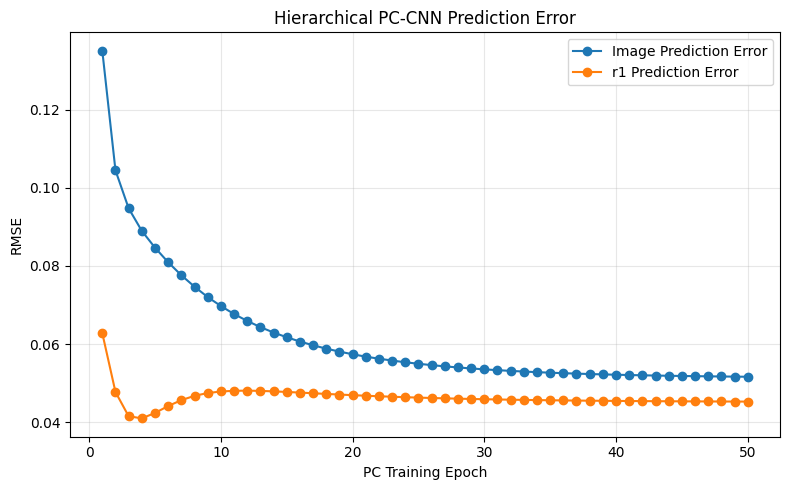

In [18]:
pc_epochs_plot = [item["epoch"] for item in pc_history]
image_error_plot = [item["image_error"] for item in pc_history]
r1_error_plot = [item["r1_error"] for item in pc_history]

plt.figure(figsize=(8, 5))

plt.plot(pc_epochs_plot, image_error_plot, marker="o", label="Image Prediction Error")
plt.plot(pc_epochs_plot, r1_error_plot, marker="o", label="r1 Prediction Error")

plt.xlabel("PC Training Epoch")
plt.ylabel("RMSE")
plt.title("Hierarchical PC-CNN Prediction Error")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

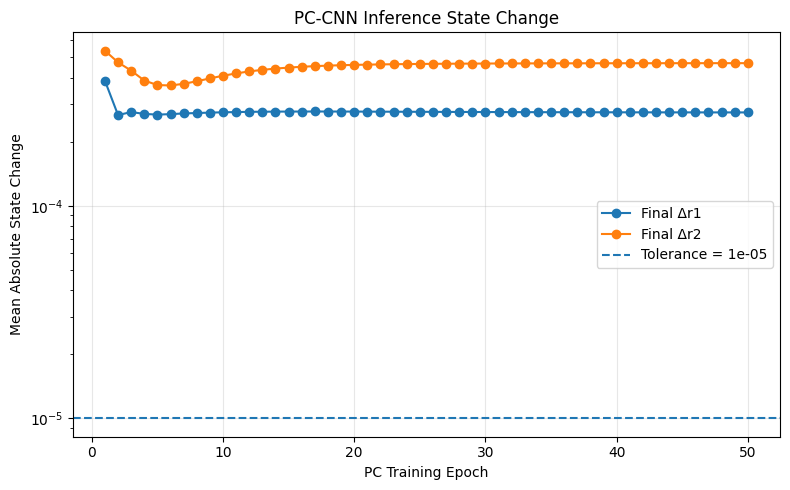

In [19]:
change_r1_plot = [item["final_change_r1"] for item in pc_history]
change_r2_plot = [item["final_change_r2"] for item in pc_history]

plt.figure(figsize=(8, 5))

plt.plot(pc_epochs_plot, change_r1_plot, marker="o", label="Final Δr1")
plt.plot(pc_epochs_plot, change_r2_plot, marker="o", label="Final Δr2")

plt.axhline(model.convergence_tolerance, linestyle="--", label=f"Tolerance = {model.convergence_tolerance}")

plt.xlabel("PC Training Epoch")
plt.ylabel("Mean Absolute State Change")
plt.title("PC-CNN Inference State Change")

plt.yscale("log")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

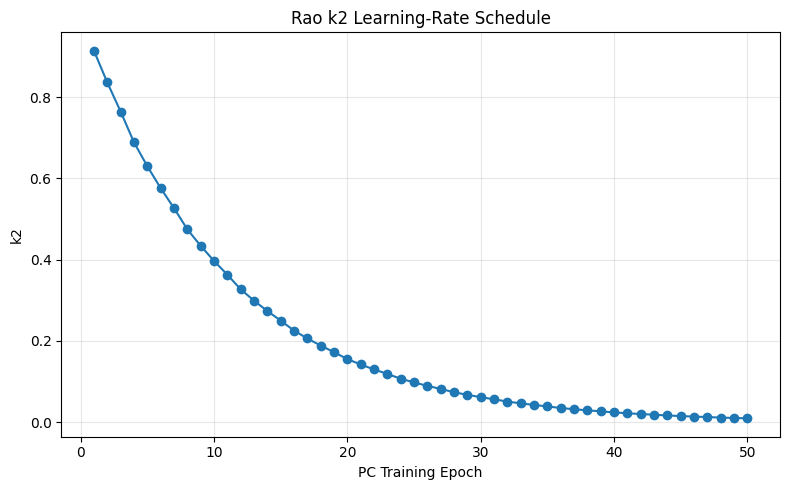

In [20]:
k2_plot = [item["k2"] for item in pc_history]

plt.figure(figsize=(8, 5))

plt.plot(pc_epochs_plot, k2_plot, marker="o")

plt.xlabel("PC Training Epoch")
plt.ylabel("k2")
plt.title("Rao k2 Learning-Rate Schedule")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

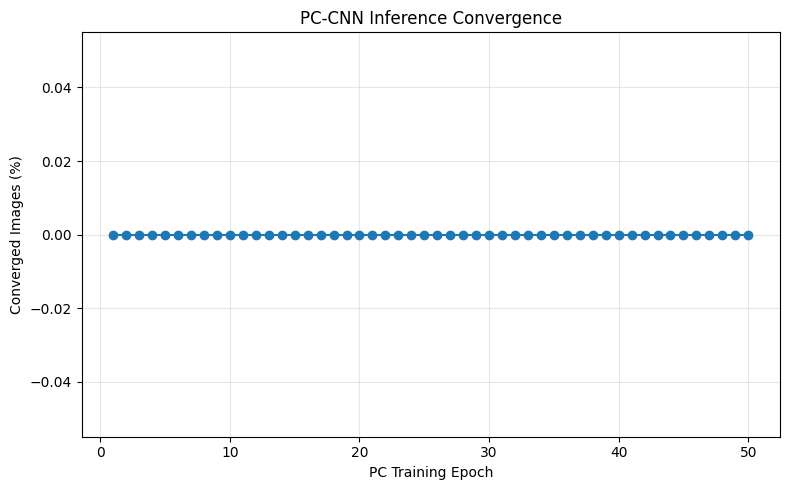

In [21]:
convergence_plot = [item["convergence_rate"] for item in pc_history]

plt.figure(figsize=(8, 5))

plt.plot(pc_epochs_plot, convergence_plot, marker="o")

plt.xlabel("PC Training Epoch")
plt.ylabel("Converged Images (%)")
plt.title("PC-CNN Inference Convergence")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
def to_display_image(image):
    image = image.detach().cpu()
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()

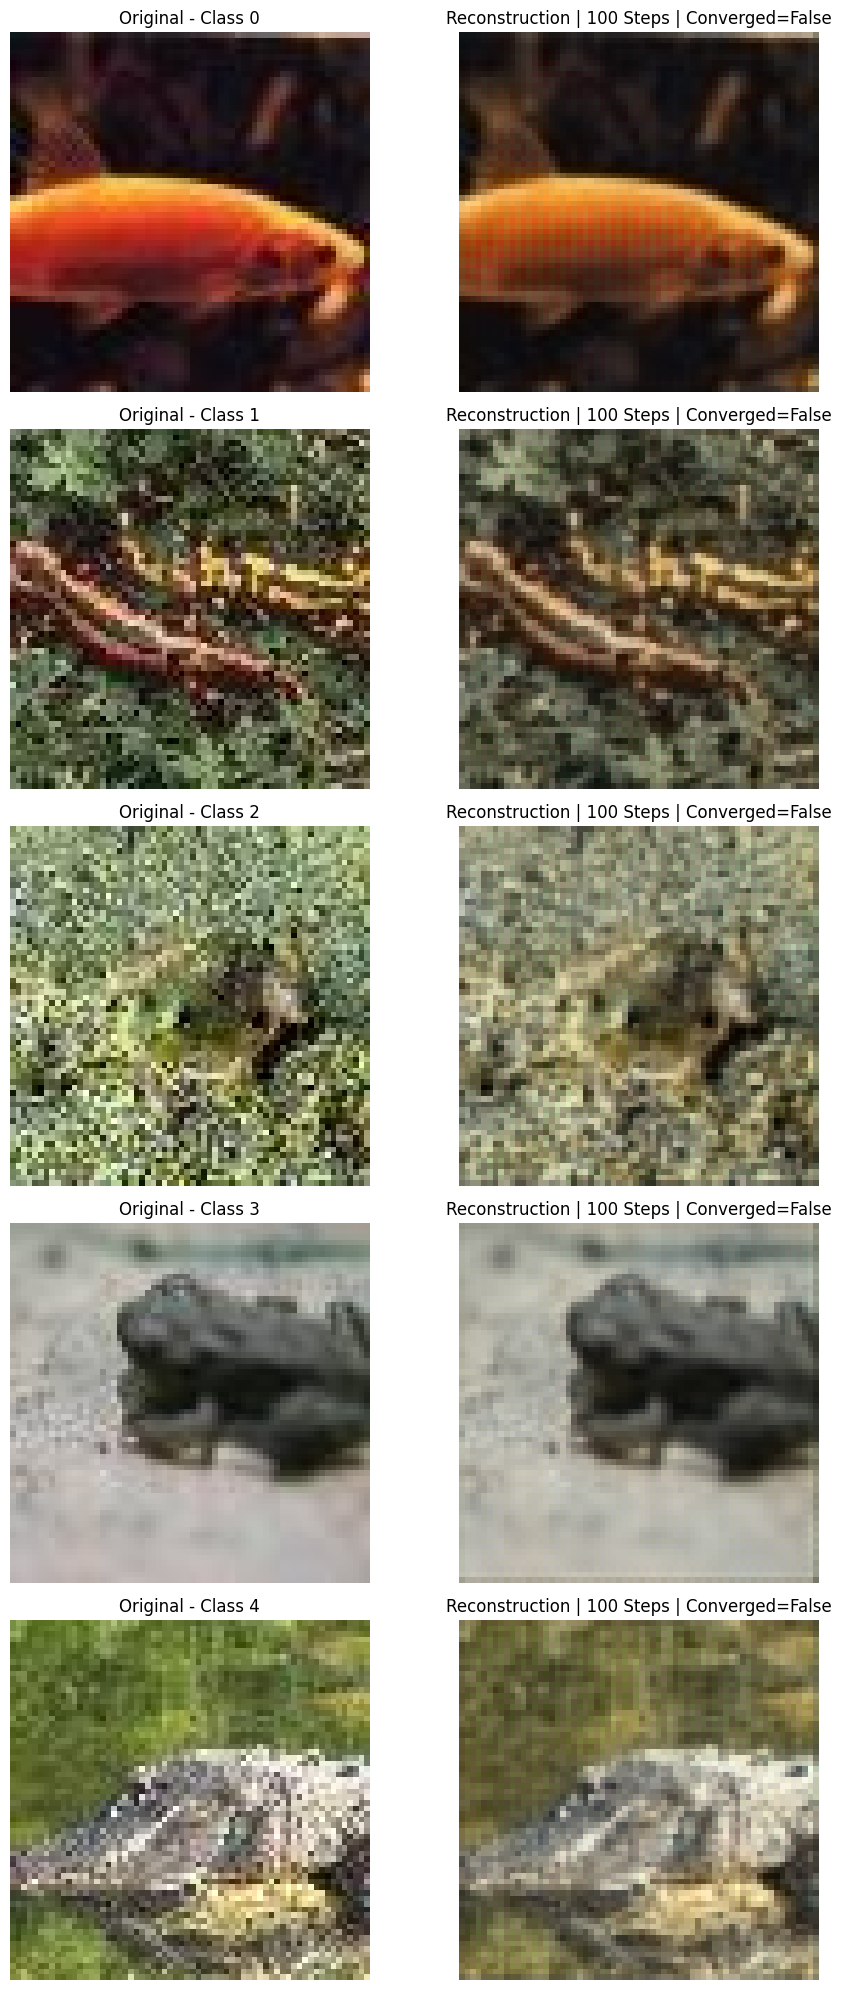

In [23]:
model.eval()

class_examples = {}

for i in range(len(train_subset)):
    image, label = train_subset[i]
    label = int(label)

    if label not in class_examples:
        class_examples[label] = image

    if len(class_examples) == NUM_CLASSES:
        break

fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(10, NUM_CLASSES * 4))

for row, class_id in enumerate(selected_classes):
    image = class_examples[class_id]

    reconstruction, predicted_r1, reconstruction_r2, r2, steps, converged = model.reconstruct(image)

    axes[row, 0].imshow(to_display_image(image))
    axes[row, 0].set_title(f"Original - Class {class_id}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(to_display_image(reconstruction))
    axes[row, 1].set_title(f"Reconstruction | {steps} Steps | Converged={converged}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [24]:
@torch.no_grad()
def train_classifier(model, train_loader, device, learning_rate):
    total_loss = 0.0
    total_correct = 0
    total_images = 0

    model.eval()

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)

        loss, correct, batch_size = model.update_classifier(images, labels, learning_rate=learning_rate)

        total_loss += loss * batch_size
        total_correct += correct
        total_images += batch_size

    online_loss = total_loss / total_images
    online_accuracy = 100.0 * total_correct / total_images

    return online_loss, online_accuracy

In [25]:
@torch.no_grad()
def evaluate_classifier(model, data_loader, device):
    total_loss = 0.0
    total_correct = 0
    total_images = 0

    model.eval()

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)

        logits = model.classify(images)

        probabilities = torch.softmax(logits, dim=1)

        true_probabilities = probabilities[torch.arange(labels.shape[0], device=labels.device), labels]

        loss = -torch.log(true_probabilities + 1e-8).mean().item()

        predictions = logits.argmax(dim=1)

        total_loss += loss * labels.shape[0]
        total_correct += (predictions == labels).sum().item()
        total_images += labels.shape[0]

    mean_loss = total_loss / total_images
    accuracy = 100.0 * total_correct / total_images

    return mean_loss, accuracy

In [26]:
classification_history = []

best_val_accuracy = -1.0
best_val_loss = float("inf")

best_epoch = None

best_classifier_weight = None
best_classifier_bias = None

for epoch in tqdm(range(CLASSIFICATION_EPOCHS), desc="Local Classification Training"):
    online_train_loss, online_train_accuracy = train_classifier(model, train_loader, device, CLASSIFIER_LEARNING_RATE)

    train_loss, train_accuracy = evaluate_classifier(model, train_eval_loader, device)
    val_loss, val_accuracy = evaluate_classifier(model, val_loader, device)

    classification_history.append({
        "epoch": epoch + 1,
        "online_train_loss": online_train_loss,
        "online_train_accuracy": online_train_accuracy,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    is_better = val_accuracy > best_val_accuracy

    if val_accuracy == best_val_accuracy and val_loss < best_val_loss:
        is_better = True

    if is_better:
        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_classifier_weight = model.classifier.weight.detach().cpu().clone()
        best_classifier_bias = model.classifier.bias.detach().cpu().clone()

    print(
        f"Epoch {epoch + 1}/{CLASSIFICATION_EPOCHS} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}% | Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")

Local Classification Training:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 1.5995 | Train Accuracy: 26.80% | Val Loss: 1.5944 | Val Accuracy: 32.00%
Epoch 2/10 | Train Loss: 1.5886 | Train Accuracy: 36.00% | Val Loss: 1.5799 | Val Accuracy: 38.67%
Epoch 3/10 | Train Loss: 1.5785 | Train Accuracy: 42.00% | Val Loss: 1.5676 | Val Accuracy: 45.33%
Epoch 4/10 | Train Loss: 1.5688 | Train Accuracy: 41.60% | Val Loss: 1.5565 | Val Accuracy: 50.67%
Epoch 5/10 | Train Loss: 1.5595 | Train Accuracy: 40.80% | Val Loss: 1.5450 | Val Accuracy: 49.33%
Epoch 6/10 | Train Loss: 1.5505 | Train Accuracy: 42.00% | Val Loss: 1.5337 | Val Accuracy: 45.33%
Epoch 7/10 | Train Loss: 1.5420 | Train Accuracy: 44.00% | Val Loss: 1.5231 | Val Accuracy: 49.33%
Epoch 8/10 | Train Loss: 1.5337 | Train Accuracy: 44.00% | Val Loss: 1.5133 | Val Accuracy: 48.00%
Epoch 9/10 | Train Loss: 1.5256 | Train Accuracy: 44.00% | Val Loss: 1.5037 | Val Accuracy: 44.00%
Epoch 10/10 | Train Loss: 1.5180 | Train Accuracy: 44.00% | Val Loss: 1.4944 | Val Accuracy: 45.33%


In [27]:
if best_classifier_weight is None:
    raise RuntimeError("No classifier checkpoint was saved.")

with torch.no_grad():
    model.classifier.weight.copy_(best_classifier_weight.to(device))
    model.classifier.bias.copy_(best_classifier_bias.to(device))

model.eval()

print("Best classifier epoch:", best_epoch)
print("Best validation accuracy:", f"{best_val_accuracy:.2f}%")
print("Best validation loss:", f"{best_val_loss:.4f}")

Best classifier epoch: 4
Best validation accuracy: 50.67%
Best validation loss: 1.5565


In [28]:
final_train_loss, final_train_accuracy = evaluate_classifier(model, train_eval_loader, device)
final_val_loss, final_val_accuracy = evaluate_classifier(model, val_loader, device)

print("Restored Best Model")
print("Train Loss:", f"{final_train_loss:.4f}")
print("Train Accuracy:", f"{final_train_accuracy:.2f}%")
print("Validation Loss:", f"{final_val_loss:.4f}")
print("Validation Accuracy:", f"{final_val_accuracy:.2f}%")

Restored Best Model
Train Loss: 1.5688
Train Accuracy: 41.60%
Validation Loss: 1.5565
Validation Accuracy: 50.67%


In [29]:
test_loss, test_accuracy = evaluate_classifier(model, test_loader, device)

print("FINAL CLEAN TEST RESULT")
print("Test Loss:", f"{test_loss:.4f}")
print("Test Accuracy:", f"{test_accuracy:.2f}%")

FINAL CLEAN TEST RESULT
Test Loss: 1.5739
Test Accuracy: 36.00%


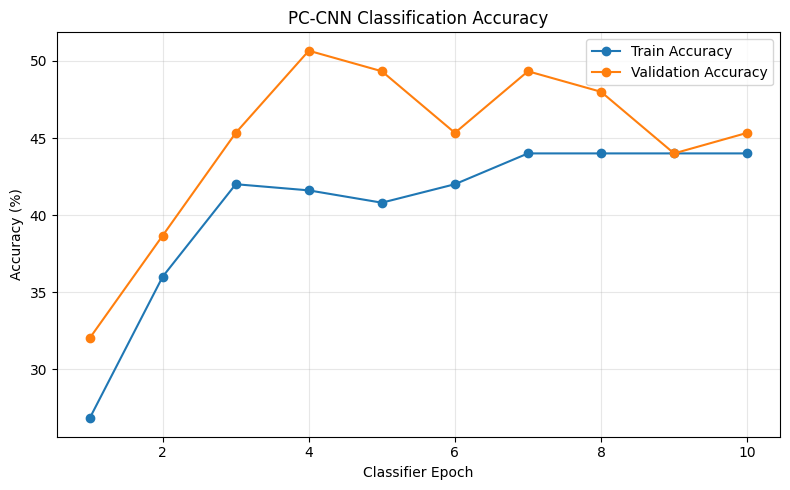

In [30]:
epochs_plot = [item["epoch"] for item in classification_history]

train_accuracy_plot = [item["train_accuracy"] for item in classification_history]
val_accuracy_plot = [item["val_accuracy"] for item in classification_history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, train_accuracy_plot, marker="o", label="Train Accuracy")
plt.plot(epochs_plot, val_accuracy_plot, marker="o", label="Validation Accuracy")

plt.xlabel("Classifier Epoch")
plt.ylabel("Accuracy (%)")
plt.title("PC-CNN Classification Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

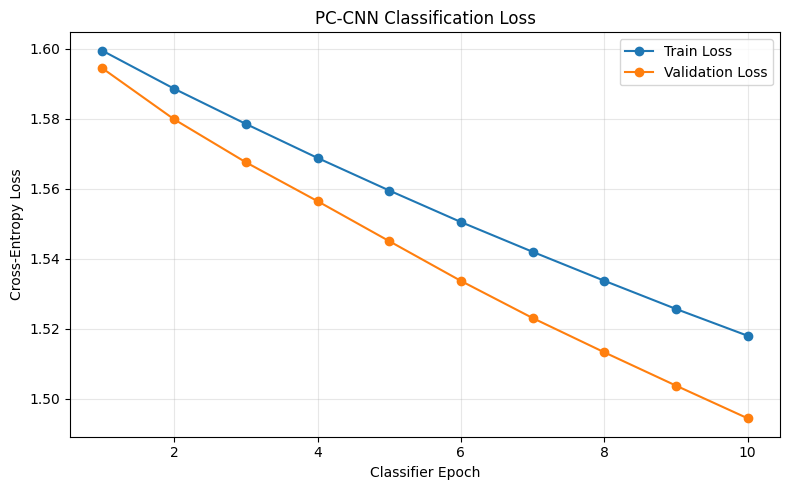

In [31]:
train_loss_plot = [item["train_loss"] for item in classification_history]
val_loss_plot = [item["val_loss"] for item in classification_history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, train_loss_plot, marker="o", label="Train Loss")
plt.plot(epochs_plot, val_loss_plot, marker="o", label="Validation Loss")

plt.xlabel("Classifier Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("PC-CNN Classification Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
print("=" * 60)
print("HIERARCHICAL RAO PC-CNN EXPERIMENT SUMMARY")
print("=" * 60)

print("Device:", device)
print("Number of classes:", NUM_CLASSES)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Test images:", len(test_subset))

print("PC epochs:", PC_EPOCHS)
print("Inference steps:", INFERENCE_STEPS)
print("Convergence tolerance:", model.convergence_tolerance)

print("Final mean Δr1:", pc_history[-1]["final_change_r1"])
print("Final mean Δr2:", pc_history[-1]["final_change_r2"])
print("Final convergence rate:", f'{pc_history[-1]["convergence_rate"]:.2f}%')

print("PC training presentations:", model.training_input_count)
print("Final k2:", model.k2)

print("Classifier epochs:", CLASSIFICATION_EPOCHS)
print("Best classifier epoch:", best_epoch)

print("Final training accuracy:", f"{final_train_accuracy:.2f}%")
print("Best validation accuracy:", f"{best_val_accuracy:.2f}%")

print("Final clean test loss:", f"{test_loss:.4f}")
print("Final clean test accuracy:", f"{test_accuracy:.2f}%")

print("=" * 60)

HIERARCHICAL RAO PC-CNN EXPERIMENT SUMMARY
Device: mps
Number of classes: 5
Training images: 250
Validation images: 75
Test images: 50
PC epochs: 50
Inference steps: 100
Convergence tolerance: 1e-05
Final mean Δr1: 0.0002747364580864087
Final mean Δr2: 0.00046847023046575484
Final convergence rate: 0.00%
PC training presentations: 12500
Final k2: 0.00960715545697016
Classifier epochs: 10
Best classifier epoch: 4
Final training accuracy: 41.60%
Best validation accuracy: 50.67%
Final clean test loss: 1.5739
Final clean test accuracy: 36.00%
